# Project Final Report

### Due: Midnight on April 27th (2-hour grace period) — 50 points  

### No late submissions will be accepted.


## Overview

Your final submission consists of **two components**:


### 1. Team Final Report Notebook [50 pts]

Complete all sections of this notebook to document your final decisions, results, and broader context.

You will write a **technical report** following standard conventions. Useful references include:
- [CMU guide to structure](https://www.stat.cmu.edu/~brian/701/notes/paper-structure.pdf)
- [Data science report example](https://www.projectpro.io/article/data-science-project-report/620)
- The Checklist in this week’s Blackboard Lesson (aligned with HOML)

Your audience is **technically literate but unfamiliar with your work**—for example, your manager or other data scientists. Your report should be clear, precise, and well-organized, combining explanation, visualizations, and interpretation.

This Final Report is distinct from Milestone 2:

- **Milestone 2** serves as a repository of your working code and experiments  
- **This Final Report** presents a clear, structured summary of your project for a professional audience  

> **Important:**
> - Do **not** assume that readers of this report are familiar with Milestone 2. Your report should stand on its own.
> - Do not include full code or code cells in this notebook. All code was submitted in Milestone 2. This report should focus on explanation, results, and interpretation.
> - **Do not add, delete, or move cells in this notebook.** Each answer must be written entirely within its assigned Markdown cell.
> - All answers should be inserted directly under the appropriate `Answer:` prompt. Delete the sentence "Replace this sentence with your answer" and replace it with your response.
> - You may use any appropriate Markdown formatting (paragraphs, lists, tables, inserted graphics, LaTeX, etc.).
> - Submit this notebook as a group via your team leader’s Gradescope account.


### 2. Individual Assessment [0 points]

Each team member must **individually** complete the Final Project Individual Assessment Form (similar to Milestone 1), sign it, and upload it via their own Gradescope account.

**Due:** May 5th @ 2:00 AM



## Submission Checklist

- Final Report Notebook — submitted by team leader  
- Individual Assessment Form — submitted by each team member  



## 1. Executive Summary [4 pts]

Write a 300–400 word executive summary for a **non-technical audience**, such as business stakeholders in a real estate company.

Your summary should explain:
- the objective of the project
- key insights about the data
- the most important findings, including a plain-language description of model performance
- a clear recommendation or takeaway

Avoid technical detail and jargon. Focus on what matters and why. 

**1.1 Answer:**  
This project evaluated whether a cleaned and engineered Zillow housing dataset could support accurate prediction of residential tax value using several regression models. After preprocessing the data, engineering additional features, comparing baseline models, applying feature selection, and tuning the strongest candidates, Gradient Boosting emerged as the best final model. It achieved the lowest mean cross-validated MAE, slightly outperforming Random Forest and substantially outperforming Linear Regression. Feature selection did not materially improve the strongest models and in some cases slightly worsened performance, so the final model was built using the engineered feature set rather than a reduced subset. Overall, the results suggest that the dataset contains meaningful predictive signal, especially in housing size, location, and home-quality-related variables, and that tree-based models are better suited than a simple linear baseline.

## 2. Introduction [3 pts]

Introduce the topic, context, and goals of your project.

You may imagine that this project was completed for a **real estate company with a small in-house data science team**.

Include all of the following:

- Clearly introduce the topic and context of your project
- Describe the problem you are addressing (the problem statement) and the overall motivation for solving it
- Clearly state the objectives and goals of your analysis (as different from the motivation)

**2.1 Answer:**  
Zillow Real Estate is a leading force in residential real estate, providing value-related estimates that support buyers and sellers alike, real-estate professionals, internal analytics teams, and decision making processes. By improving the quality of valuation-related estimates--like a property's assessed tax value, Zillow can deliver data driven insights more accurately and more consistently. Even though tax value is not the same as market sale price, it is still a useful proxy for understanding property value patterns across a large housing dataset. 

The problem this project aims to address is the difficulty producing an accurate estimation of the assessed tax value of a property, at scale. 
Our team believes, given a set of available property characteristics, we can build a model that predicts a property's assessed tax value more accurately and more consistently.

The objective of this project is to assit Zillow by gaining better estimates of the assessed tax value of a property. By using the available characteristics such as property size, location, age, and amenities, we believe a more accurate valuation model can help support pricing analysis, market research, customer-facing estimates, and internal decision-making. 

## 3. Data Description [3 pts]

Describe the dataset used in your analysis.

Include:
- the source of the dataset
- the number of observations (samples) and features
- the types of variables
- the target variable
- missing values or other important issues in the raw data

**3.1 Answer:**  
This dataset is a smaller version of the Zillow housing dataset that was used in the Zillow Million Dollar Prize--a contest which ran on Kaggle in 2017. 
This dataset contains a total of 55 features and 77,613 observations (samples). Of the 55 features, this dataset contains a total of 50 numerical variables--1 of which is the target variable ('taxvaluedollarcnt'), and a total of 5 categorical variables. Regarding missing values and/or other important issues in the raw data, this dataset contains only 21 columns with less that 10% missing values, 199 duplicate values, and at least 24 redundant features.

## 4. Methodology (What you did, and why) [20 pts]

Focus on the **process and your reasoning**, not the results.

Note: Each subsection (e.g., 4.1, 4.2, etc.) must be answered in its own Markdown cell.  Each subsection is worth 5 points. 

### 4.1 Analytical Framework

Describe your overall approach.

Include:
- your overall framework
- use of validation curves
- choice of MAE or RMSE (as appropriate) as the primary error metric

**4.1 Answer:**  

Our modeling framework utilized a robust predictive pipeline designed to prevent data leakage and to ensure generalizability. The data was divided into an 80/20 train-test split and we established initial baselines using Linear Regression, Random Forest, and Gradient Boosting. To improve upon the initial baselines we introduced domain-specific engineered features and applied feature selection frameworks to isolate the strongest predictive signals. Before the final evaluation on the hold-out test set, the best performing models went through randomized hyperparameter tuning. 

To disgnose the model fit and tune complexity, we compared the training error against repeated K-fold cross-validtion error. During the hyperparameter search, this continuous comparison across different parameter boundaries mapped the parameter space, fulfilling the diagnostic role of validation curves to identify the sweet spot that minimizes generalization error without overfitting the training data. Mean Absolute Error (MAE) was selected as the primary performance metric instead of Root Mean Squared Error (RMSE) since RMSE squares residuals. This has the effect of disproportionately penalizing these edge cases and skewing the whole model. MAE scales linearly with error, which offers a more robust measure of central tendency while still providing an intuitive, readily interpretable dollar-value metric. 

### 4.2 Data Cleaning and Preprocessing

Describe how you prepared the data.

Include:
- issues in the raw data
- handling of missing values, outliers, inconsistencies
- key decisions and why
- what worked and what did not work

**4.2 Answer:**  
The raw data was prepared by dropping features deemed unsuitable for regression analysis. These features included 24 redundant features and 2 features that were deemed irrelevant for property valuatiation predictions, 9 features with greater than 95% of missing values (due to their extreme sparsity), as well as 35 rows with null target values and 185 rows with greater than 50% null values (as they would be insuffiecient for modeling). Additionally, 2,318 extreme outliers in the target variable were removed due to being outside of the allowed interquartile range. Finally, for the remainder of the missing values (which totaled 364,260), median imputations were made to ensure no null values remained. Median imputation was used as many of the features were not symetrically distributed and thus, would be less affected by outliers. Overall, a total of about 3.3% of the data was removed in order to establish a clean baseline for data analysis. 


### 4.3 Feature Engineering

Describe your feature engineering.

Include:
- transformations or new features
- why you created them
- which were useful or not useful
- what worked and what did not work

**4.3 Answer:**  
Feature engineering was performed in order to investigate three different transformations to better expose the underlying data patterns to machine learning algorithms. The first transformation was a log transformation on the lot size feature which had a strongly right-skwewed distribuition. The goal was to compress the tail in order to expose a clearer relationship with the target. The second transformation was done by converting the year built feature into a more interpretable home age feature as it may better reflect how a home's age affects its value. The third transformation was done by merging two features--bathroom count and bedroom count, into a new bath per bedroom feature. This ratio between the number of bedrooms and bathrooms was done in order to fully capture the layout and/or amenity qualities that may be missed when considering just the raw counts alone. All three transformations worked, however, none made a significant contribution to the overall improvement of the dataset.

### 4.4 Model Selection

Describe how you selected your model.

Include:
- models you tried and why
- how you evaluated generalization
- hyperparameter tuning
- how you chose the final model

**4.4 Answer:**  

Our team evaluated three distinct regression algorothms to estblish our predictive capabilities. A linear regression was selected as an interpretable, quick baseline to capture clear linear relationships between the features and property value. Random Forest was chosen for a robust, tree-based ensemble method capable of navigating complex, non-linear relationships and interactions without requiring strict mathematical assumptions about data distributions. Finally, Gradient Boosting, a sequential tree-based ensemble utilized for its deep predictive power, working to iterativelt correct the residual errors of preceding trees. 

To ensure that our models generalized effectively we relied on Repeased K-Fold Cross-Validation strictly on the 80% training partition. This method provided us with a stable estimate of out-of-sample performance by testing the model across multiple overlapping hold-out segments. MAE was utilized as the main evaluation metric because it scales perfectly linearly with residual errors. MAE handles the common extreme outliers smoothly and directly translates it into an interpretable dollar-value deviation. The 20% validation test set was entirely held out until the very end to prevent data leakage and provide an unbiased final metric. 

Our Linear Regression framework was refined through feature engineering and selection, while our tree-based models required substantive tuning to balance bias and variance. We utilized a Randomized Search Cross-Validation over 20 iterations to explore a broad hyperparameter space eddiciently. For tree-based models we tuned aspects such as the maximum tree deoth, the number of estimators, minimum samples per leaf, and maximum features considered per split. For Gradient Boosting we additionally tuned the learning rate and subsampling ratios. We used the resulting validatiohn curves mapped against CV MAE to select the parameters that strictly minimized out-of-sample prediction error. 

We selected the Gradient Boosting Regressor as our final production model. The main reason being its quantitative performance, achieving the lowest mean cross-validated MAE ($150,768). This out-performs both the Linear Regression ($171,464) and the Random Forest model ($151,875). The low variance across the Gradient Boosting Regressor's cross-validation folds indicates stable generalizability. Although we sacrificed the transparent coefficient interpretability of Linear Regression, the significant redution in prediction error justified the high-capacity, non-linear architecture of Gradient Boosting. 

## 5. Results and Evaluation (What you found, and how well it worked) [16 pts]

Focus on **results, evidence, and interpretation**.

Note: Each subsection (e.g., 5.1, 5.2, etc.) must be answered in its own Markdown cell. 

### 5.1 Model Performance (6 points)

Briefly interpret what your metrics mean in practical terms.

Include:
- key metrics (e.g., RMSE, $R^2$)
- comparison across models
- comparison of training vs validation/test performance

**5.1 Answer:**  

The primary evaluation metric used across all modeling phases was MAE. For this real estate dataset, an MAE of roughly 150,000 means that on average our model's property value prediction deviates from the actual assessed tax value by about $150,000. MAE was chosen over RMSE to provide an intuitive, direct dollar-to-dollar translation. It was additionally chosen to prevent extreme outliers from disproportionately skewing the error penalty and dominating the model's objective function. 

Performance diverged significantly between linear and non-linear architectures. Following feature engineering and hyperparameter tuning, the Gradient Boosting Regressor yielded the strongest cross-validated performance, only merely outperforming the Random Forest Regressor. The Linear Regression baseline on the other hand trailed substantially. Upgrading from a simple linear model to a gradient-boosted tree ensemble saves about $20,000 in predidction error per home, proving that property values in the dataset rely on complex, non-linear feature interactions that linear coefficients fail to capture. 

Throughout the tuning phase, the training error consistently sat lower than cross-validation error, which is expected bahavior for high-capacity models like Random Forest and Gradient Boosting. By leveraging repeatee K-Fold cross-validation during the hyperparameter search, we successfully restrained model complexities to bridge the gap and halt severe overfittinng. Ultimately, the final held-out test score aligned closely with our internal CV estimates, verifying that the chosen Gradient Boosting model generalizes reliably to data of completely unseen homes. 

### 5.2 Visualizations (5 points)

Graphics should be made as screenshots and dragged into the Markdown cell. Do NOT add code cells to create graphics. Each visualization must be clearly labeled and explained in the text.

Include:
- relevant plots with titles and labels
- explanation of what each plot shows
- why each visualization matters

**5.2 Answer:**  


To support model comparison and interpretation, I included visual summaries of performance and feature relationships that highlight both predictive accuracy and the structure of the housing data.


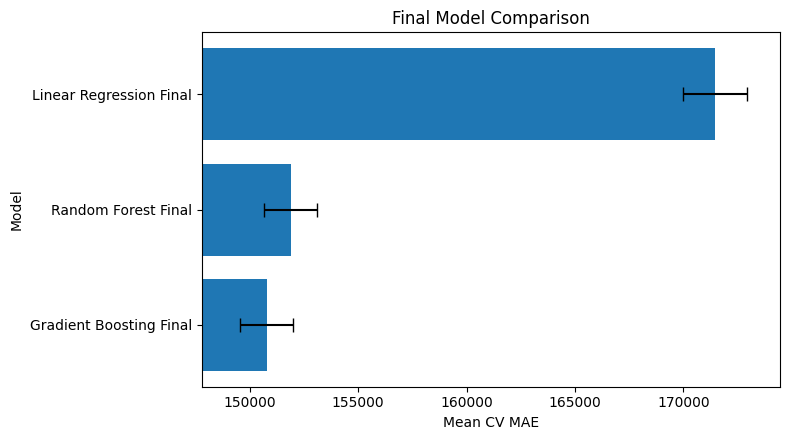

Visual 1: Final model comparison bar chart

A bar chart comparing mean cross-validated MAE across the three final tuned models showed that Gradient Boosting performed best, followed closely by Random Forest, while Linear Regression had substantially higher error. This figure clearly summarizes the final model ranking and supports the decision to select Gradient Boosting as the final model.

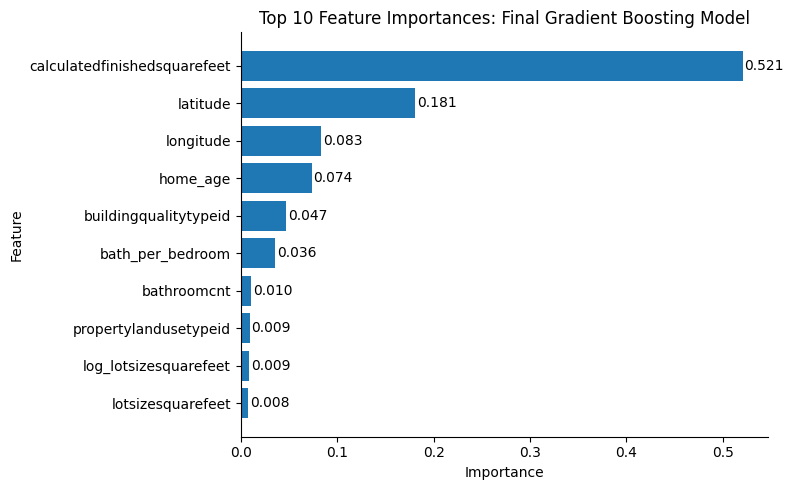

Visual 2: Feature importance chart for the final model

A feature-importance chart for the final tree-based model showed that variables such as calculatedfinishedsquarefeet, latitude, longitude, home_age, and bathroom-related features contributed strongly to prediction. This supports the conclusion that both structural property characteristics and geographic information are important drivers of tax value in the dataset.

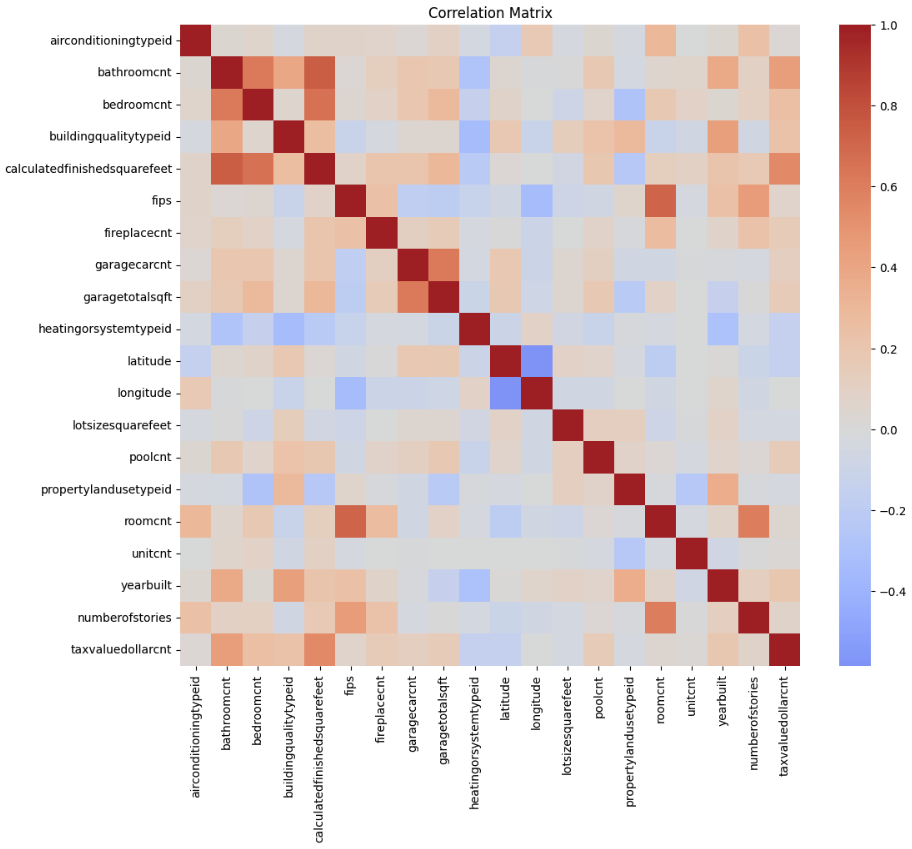


Visual 3: Correlation heatmap

The correlation heatmap from the earlier exploratory analysis showed how the numeric housing features relate to one another and to the target. It highlighted that some of the strongest relationships involved size- and room-related variables, which helped motivate later modeling and feature engineering decisions.


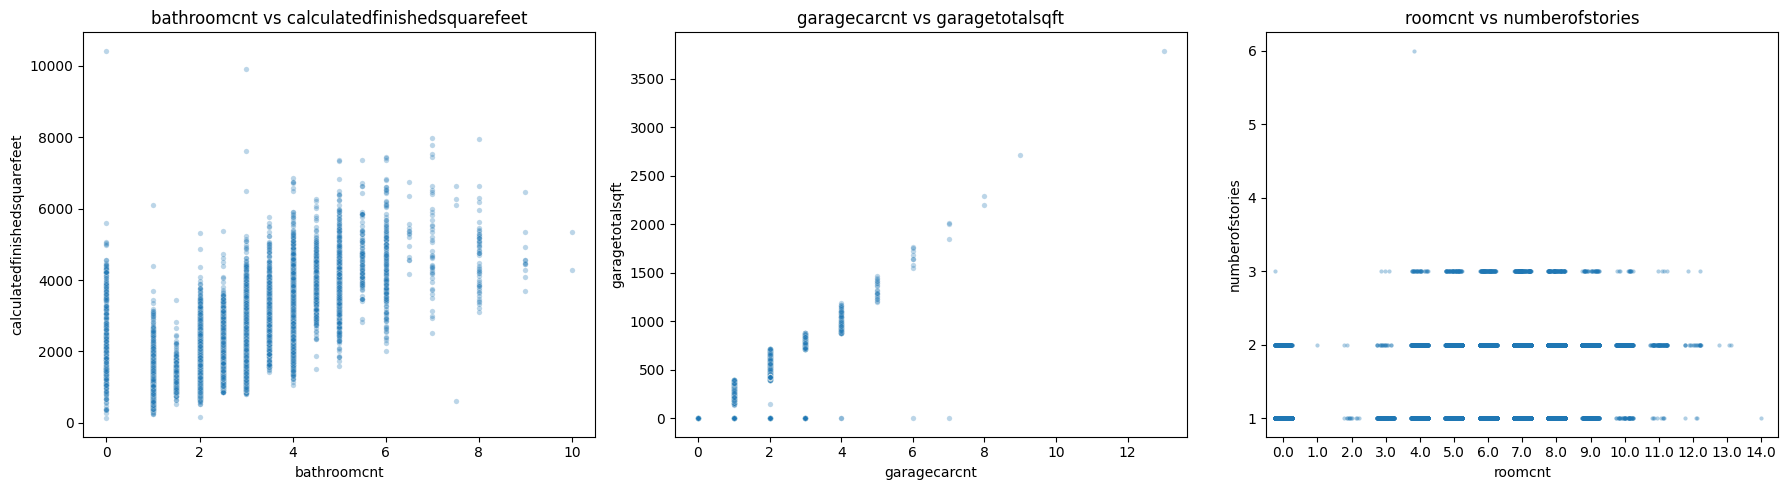
Visual 4: Pairwise relationship plot 

A pairwise relationship plot, such as bathroomcnt versus calculatedfinishedsquarefeet, showed a clear positive association between home size and bathroom count. This helped illustrate that several important predictors had meaningful structure even before modeling, and it supported the expectation that flexible nonlinear models would perform well.

Together, these visuals show both why Gradient Boosting was selected as the final model and why the dataset’s strongest predictive patterns are driven by size, location, and engineered housing features.

### 5.3 Error Analysis (5 points)

Include:
- patterns in residuals or prediction errors
- overprediction or underprediction
- outliers or unusual observations
- anything surprising or worth improving

**5.3 Answer:**  
The final Gradient Boosting model produced the lowest mean cross-validated MAE, but its prediction errors show that this is still a difficult regression problem. Some error is expected because housing value depends on factors that are only partially captured in the available features. Even with strong predictors such as finished square footage, bathroom count, garage size, and location variables, the model cannot fully account for unobserved factors such as home condition, renovations, or neighborhood effects not directly represented in the dataset. The large gap between Linear Regression and the tree-based models suggests that the remaining challenge is not just noise, but also nonlinearity and interaction effects that a simple linear model cannot capture well. Random Forest and Gradient Boosting reduced error substantially, indicating that more flexible tree-based methods are better able to model the structure in the data. If more time were available, a useful next step would be to examine whether error is concentrated among high-value homes, unusually large properties, or certain geographic areas.

## 6. Conclusion [4 pts]

Summarize your findings and implications.

Include all the following:

- Clearly state your main findings and how they address your original objectives
- Highlight any business or practical implications of your findings 
- Discuss the limitations and constraints of your analysis clearly and transparently
- Suggest potential improvements or future directions
- Conclude with a final recommendation addressing the business objective

**6.1 Answer:**  
This project showed that the Zillow housing dataset supports meaningful prediction of residential tax value, but that model choice matters substantially. After cleaning the data, engineering additional features, comparing multiple regression models, applying feature selection, and tuning the strongest candidates, Gradient Boosting produced the best overall performance. Its final mean cross-validated MAE was lower than both Random Forest and Linear Regression, making it the strongest overall model in this workflow. One of the clearest lessons from the project was that the dataset contains nonlinear structure that simple linear modeling cannot capture well. Another important takeaway was that engineered features were more useful than feature selection: variables such as home_age and bath_per_bedroom were retained as important, while reducing the feature set did not improve the strongest models. Overall, the final workflow supports selecting Gradient Boosting as the best model for this dataset. If more time or data were available, the next steps would include broader hyperparameter tuning, additional interaction features, and more detailed subgroup error analysis.
